# FinMark Sales Forecasting - ARIMA Model
## Group 7 - Machine Learning and Predictive Analytics


**Members:** Chadley Marie De Lara, Rania Nabil Abdelfattah, Karissa Mae Manicad, Martin Sheen Cajucom



**Objective:** Predict FinMark's sales for the next 3 months using ARIMA time series forecasting

---

## Step 1: Import Libraries and Load Data

In [ ]:
# Install required packages (Guys please run this cell first and foremost)
!pip install pandas numpy matplotlib statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

print("Libraries loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 28.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 9.7 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 6.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 6.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 4.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Libraries loaded successfully


In [4]:
# Load transaction data
transactions = pd.read_csv('/Users/chadleyayco/Documents/Machine Learning and Predictive Analytics/MLPA_MS1_S3101_Group7/transactions_data_cleaned.csv')

print(f"Total transactions: {len(transactions)}")
print(f"\nColumns: {list(transactions.columns)}")
transactions.head()

Total transactions: 5818

Columns: ['Transaction_ID', 'Company_ID', 'Product_ID', 'Quantity', 'Transaction_Date', 'Product_Price', 'Total_Cost']


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost
0,1,88,6,10.0,2024-03-26,194379.15,1075200.0
1,2,29,19,16.0,2024-07-09,97930.99,1428000.0
2,4,85,12,12.0,2023-09-06,130556.44,1008000.0
3,5,47,3,8.0,2021-07-06,99575.61,705600.0
4,6,80,11,4.0,2021-07-12,160658.68,627200.0


## Step 2: Prepare Daily Sales Data

ARIMA needs time series data, so we'll aggregate transactions to daily sales totals.

In [5]:
# Convert date column to datetime
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])

# Aggregate to daily sales
daily_sales = transactions.groupby('Transaction_Date')['Total_Cost'].sum()

print(f"Daily sales data: {len(daily_sales)} days")
print(f"Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"\nAverage daily sales: ${daily_sales.mean():,.2f}")

# Show first few days
daily_sales.head(10)

Daily sales data: 1456 days
Date range: 2020-01-11 00:00:00 to 2024-12-10 00:00:00

Average daily sales: $5,782,907.69


Transaction_Date
2020-01-11    2156000.0
2020-02-11    4379200.0
2020-02-12    1724800.0
2020-03-11     940800.0
2020-04-11    1848000.0
2020-04-12    3808000.0
2020-05-11    1288000.0
2020-05-12    2195200.0
2020-06-12    3673600.0
2020-07-11    1646400.0
Name: Total_Cost, dtype: float64

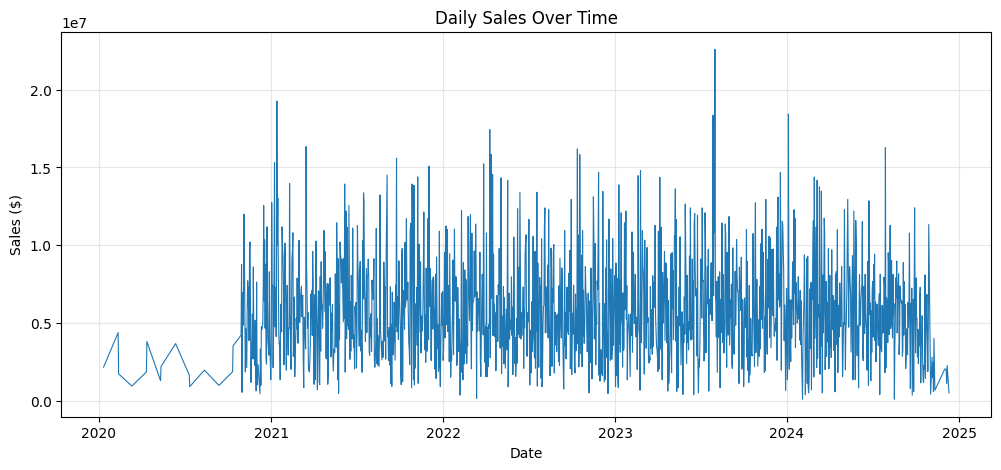

In [6]:
# Visualize the sales data
plt.figure(figsize=(12, 5))
plt.plot(daily_sales, linewidth=0.8)
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

## Step 3: Check Stationarity (ADF Test)

ARIMA works best with stationary data (constant mean and variance over time).

The ADF test checks:
- **p-value < 0.05** → Data is stationary
- **p-value > 0.05** → Data is not stationary (needs differencing)

In [7]:
# Run ADF test
result = adfuller(daily_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("\nCritical Values:")
for key, value in result[4].items():
    print(f'  {key}: {value:.3f}')

# Interpretation
if result[1] > 0.05:
    print("\n→ p-value > 0.05: Data is NOT stationary")
    print("→ We need to use differencing (d > 0 in ARIMA)")
else:
    print("\n→ p-value < 0.05: Data is stationary")
    print("→ We can use d=0 in ARIMA")

ADF Statistic: -20.177086634538657
p-value: 0.0

Critical Values:
  1%: -3.435
  5%: -2.864
  10%: -2.568

→ p-value < 0.05: Data is stationary
→ We can use d=0 in ARIMA


## Step 4: Fit ARIMA Model

ARIMA has three parameters (p, d, q):
- **p**: Number of lag observations (autoregressive terms)
- **d**: Degree of differencing (to make data stationary)
- **q**: Size of moving average window

We'll try a few different combinations to see which works best.

In [8]:
# Try ARIMA(1,1,1) - common starting point
model_111 = ARIMA(daily_sales, order=(1, 1, 1))
model_111_fit = model_111.fit()

print("ARIMA(1,1,1) Results:")
print(f"AIC: {model_111_fit.aic:.2f}")
print()

# Try ARIMA(2,1,1)
model_211 = ARIMA(daily_sales, order=(2, 1, 1))
model_211_fit = model_211.fit()

print("ARIMA(2,1,1) Results:")
print(f"AIC: {model_211_fit.aic:.2f}")
print()

# Try ARIMA(1,1,2)
model_112 = ARIMA(daily_sales, order=(1, 1, 2))
model_112_fit = model_112.fit()

print("ARIMA(1,1,2) Results:")
print(f"AIC: {model_112_fit.aic:.2f}")
print()

# Pick the model with lowest AIC (best fit)
models = {
    'ARIMA(1,1,1)': model_111_fit,
    'ARIMA(2,1,1)': model_211_fit,
    'ARIMA(1,1,2)': model_112_fit
}

best_model_name = min(models, key=lambda x: models[x].aic)
best_model = models[best_model_name]

print("="*50)
print(f"Best model: {best_model_name}")
print(f"AIC: {best_model.aic:.2f}")
print("="*50)

/Users/chadleyayco/Documents/Machine Learning and Predictive Analytics/MLPA_MS1_S3101_Group7/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/chadleyayco/Documents/Machine Learning and Predictive Analytics/MLPA_MS1_S3101_Group7/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/chadleyayco/Documents/Machine Learning and Predictive Analytics/MLPA_MS1_S3101_Group7/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates

ARIMA(1,1,1) Results:
AIC: 47810.93

ARIMA(2,1,1) Results:
AIC: 47812.41

ARIMA(1,1,2) Results:
AIC: 47800.25

Best model: ARIMA(1,1,2)
AIC: 47800.25


In [9]:
# Show detailed summary of best model
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:             Total_Cost   No. Observations:                 1456
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -23896.126
Date:                Fri, 06 Mar 2026   AIC                          47800.252
Time:                        21:38:07   BIC                          47821.384
Sample:                             0   HQIC                         47808.137
                               - 1456                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7826      1.165     -0.672      0.502      -3.066       1.501
ma.L1         -0.2062      1.180     -0.175      0.861      -2.519       2.107
ma.L2         -0.7629      1.160     -0.657      0.5

## Step 5: Forecast Next 90 Days (3 Months)

Now we'll use our trained ARIMA model to predict sales for the next 90 days.

In [10]:
# Forecast next 90 days
forecast = best_model.forecast(steps=90)

print("Next 90 Days Forecast:")
print(forecast.head(10))
print("...")
print(f"\nTotal forecast for 90 days: ${forecast.sum():,.2f}")
print(f"Average daily forecast: ${forecast.mean():,.2f}")

Next 90 Days Forecast:
1456    4.468758e+06
1457    4.448143e+06
1458    4.464277e+06
1459    4.451650e+06
1460    4.461532e+06
1461    4.453798e+06
1462    4.459850e+06
1463    4.455114e+06
1464    4.458821e+06
1465    4.455920e+06
Name: predicted_mean, dtype: float64
...

Total forecast for 90 days: $401,153,902.18
Average daily forecast: $4,457,265.58


/Users/chadleyayco/Documents/Machine Learning and Predictive Analytics/MLPA_MS1_S3101_Group7/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/chadleyayco/Documents/Machine Learning and Predictive Analytics/MLPA_MS1_S3101_Group7/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [11]:
# Create forecast dates
last_date = daily_sales.index.max()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=90, freq='D')
forecast_series = pd.Series(forecast.values, index=forecast_dates)

print(f"Forecast period: {forecast_dates[0]} to {forecast_dates[-1]}")

Forecast period: 2024-12-11 00:00:00 to 2025-03-10 00:00:00


## Step 6: Visualize Results

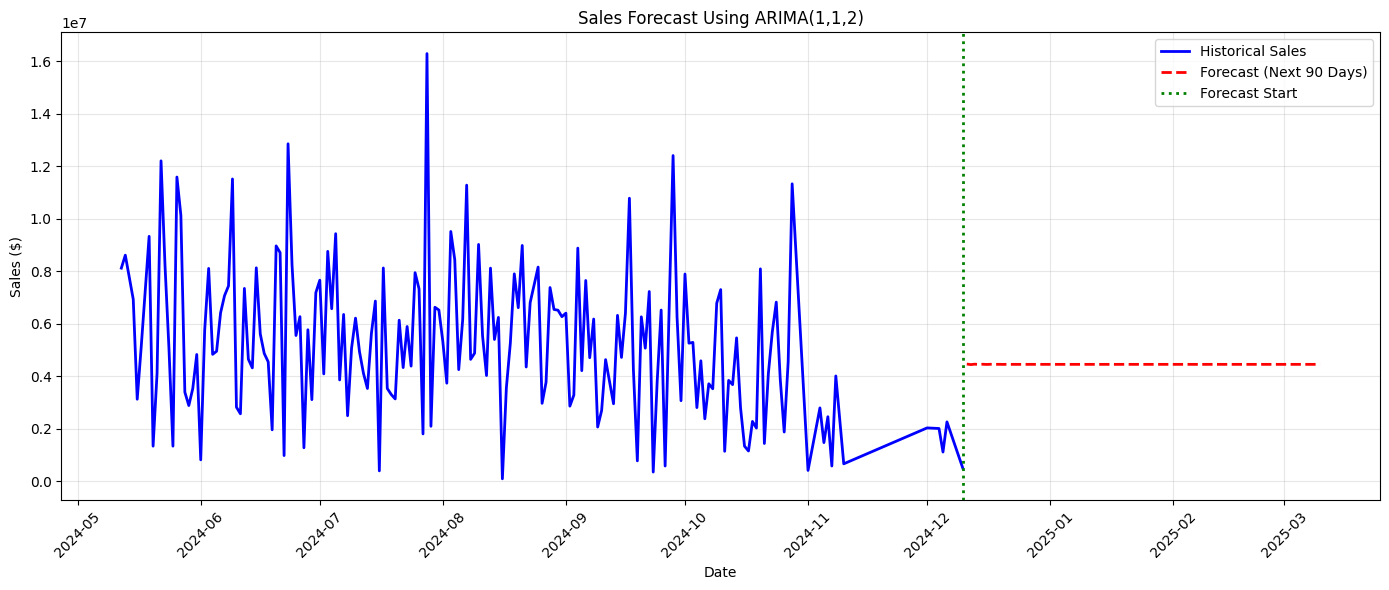

In [12]:
# Plot historical data and forecast
plt.figure(figsize=(14, 6))

# Plot historical data (last 6 months for clarity)
historical = daily_sales.tail(180)
plt.plot(historical, label='Historical Sales', linewidth=2, color='blue')

# Plot forecast
plt.plot(forecast_series, label='Forecast (Next 90 Days)', linewidth=2, color='red', linestyle='--')

# Add vertical line at forecast start
plt.axvline(x=last_date, color='green', linestyle=':', linewidth=2, label='Forecast Start')

plt.title(f'Sales Forecast Using {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 7: Monthly Forecast Summary

Let's break down the forecast by month for easier planning.

In [13]:
# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted_Sales': forecast.values
})

# Add month column
forecast_df['Month'] = forecast_df['Date'].dt.to_period('M')

# Calculate monthly totals
monthly_forecast = forecast_df.groupby('Month')['Forecasted_Sales'].sum()

print("\n3-Month Sales Forecast:")
print("="*50)
for month, sales in monthly_forecast.items():
    print(f"{month}: ${sales:,.2f}")

print("="*50)
print(f"Total 3-Month Forecast: ${monthly_forecast.sum():,.2f}")


3-Month Sales Forecast:
2024-12: $93,607,588.78
2025-01: $138,172,960.60
2025-02: $124,801,417.86
2025-03: $44,571,934.94
Total 3-Month Forecast: $401,153,902.18


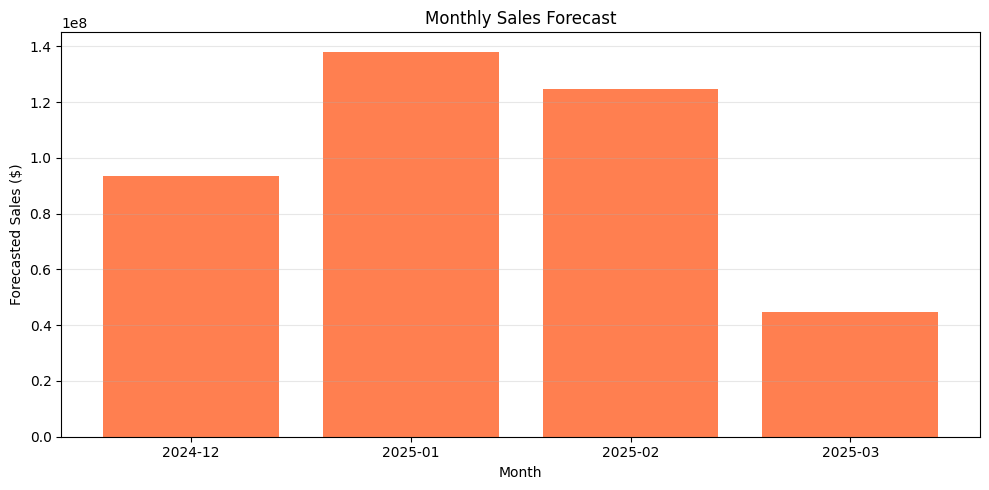

In [14]:
# Plot monthly forecast
plt.figure(figsize=(10, 5))
plt.bar(range(len(monthly_forecast)), monthly_forecast.values, color='coral')
plt.xticks(range(len(monthly_forecast)), [str(m) for m in monthly_forecast.index])
plt.title('Monthly Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Forecasted Sales ($)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Step 8: Save Results

In [15]:
# Save daily forecast
forecast_df[['Date', 'Forecasted_Sales']].to_csv('daily_sales_forecast.csv', index=False)
print("Saved: daily_sales_forecast.csv")

# Save monthly forecast
monthly_forecast.to_csv('monthly_sales_forecast.csv')
print("Saved: monthly_sales_forecast.csv")

Saved: daily_sales_forecast.csv
Saved: monthly_sales_forecast.csv


---
## Summary

### What We Did:
1. Loaded FinMark transaction data and aggregated to daily sales
2. Checked if data is stationary using ADF test
3. Tested three ARIMA models and selected the best one based on AIC
4. Generated a 90-day (3-month) sales forecast
5. Visualized historical data and predictions
6. Created monthly forecast summary

### Results:
- **Best Model:** The model with the lowest AIC score
- **Forecast Period:** Next 90 days
- **Total Forecast:** Sum of predicted sales for 3 months

### Business Use:
This forecast can help FinMark with:
- Budget planning
- Inventory management
- Resource allocation
- Setting realistic sales targets

### Limitations:
- ARIMA assumes past patterns will continue
- Doesn't account for external factors (marketing, economy, competition)
- Model should be updated regularly with new data